In [88]:
import pandas as pd 
import yfinance as yf 

# Resampling 


Resampling is an important operation on financial time series data. Usually this takes
the form of downsampling, meaning that, for example, a tick data series is resampled
to one-minute intervals or a time series with daily observations is resampled to one
with weekly or monthly observations

In [89]:
data = pd.read_csv('fxcm_eur_usd_tick_data.csv',index_col=0,parse_dates=True)

In [90]:
data.resample(rule='1min',label='right').last().head()

,Bid,Ask
2017-11-10 12:01:00,1.16406,1.16407
2017-11-10 12:02:00,1.16396,1.16397
2017-11-10 12:03:00,1.16416,1.16418
2017-11-10 12:04:00,1.16417,1.16417
2017-11-10 12:05:00,1.16425,1.16427


rule = '5min' : This defines the size of the bucket. You are telling Pandas to group all the data points that happened within the same 60-second window together. (Other common rules: '5min', '1H' for hourly, '1D' for daily)

label='right': This tells Pandas what to name the new bucket. If a bucket contains data from 09:30:00 to 09:31:00, label='right' means the resulting row will be stamped with the ending time (09:31:00). If you used label='left', it would be stamped with 09:30:00

.last() : Once Pandas groups all the data into 1-minute buckets, it needs to know what to do with the numbers inside them. Do you want the average? The sum?

By calling .last(), you are asking for the very final data point recorded in that 1-minute window. In algorithmic trading, this is exactly how you calculate the "Close" price of a 1-minute candle.

(If you wanted the "Open" price, you would use .first(). For the "High", you would use .max()).



In [91]:
data.resample(rule='5min',label='right').last()

,Bid,Ask
2017-11-10 12:05:00,1.16425,1.16427
2017-11-10 12:10:00,1.16454,1.16455
2017-11-10 12:15:00,1.16449,1.16449
2017-11-10 12:20:00,1.16437,1.16437
2017-11-10 12:25:00,1.16429,1.16430
2017-11-10 12:30:00,1.16424,1.16424
2017-11-10 12:35:00,1.16433,1.16433
2017-11-10 12:40:00,1.16439,1.16439
2017-11-10 12:45:00,1.16450,1.16451
2017-11-10 12:50:00,1.16488,1.16489


# Correlation Analysis 

consider the case of the S&P 500 stock index and the VIX volatility index. It is a styl‐
ized fact that when the S&P 500 rises, the VIX falls in general, and vice versa. This is
about correlation and not causation. This section shows how to come up with some
supporting statistical evidence for the stylized fact that the S&P 500 and the VIX are
(highly) negatively correlated.

In [92]:
# reading the data 
tickers = ["^GSPC", "^VIX"]

# Fetch historical data 
data = yf.download(tickers,period="5y")


[*********************100%***********************]  2 of 2 completed


In [93]:
data

Price             Close                    High                     Low  \
Ticker            ^GSPC       ^VIX        ^GSPC       ^VIX        ^GSPC   
Date                                                                      
2021-06-30  4297.500000  15.830000  4302.430176  17.309999  4287.959961   
2021-07-01  4319.939941  15.480000  4320.660156  16.010000  4300.729980   
2021-07-02  4352.339844  15.070000  4355.430176  15.540000  4326.600098   
2021-07-06  4343.540039  16.440001  4356.459961  17.940001  4314.370117   
2021-07-07  4358.129883  16.200001  4361.879883  17.639999  4329.790039   
...                 ...        ...          ...        ...          ...   
2026-06-24  7358.220215  18.629999  7428.060059  20.340000  7336.819824   
2026-06-25  7357.490234  18.889999  7419.080078  19.950001  7323.500000   
2026-06-26  7354.020020  18.410000  7392.950195  20.719999  7294.180176   
2026-06-29  7440.430176  17.650000  7444.319824  19.450001  7348.879883   
2026-06-30          NaN  17.590000          NaN  17.750000          NaN   

Price                         Open                   Volume       
Ticker           ^VIX        ^GSPC       ^VIX         ^GSPC ^VIX  
Date                                                              
2021-06-30  15.580000  4290.649902  16.180000  4.266040e+09    0  
2021-07-01  15.310000  4300.729980  15.620000  3.788230e+09    0  
2021-07-02  14.250000  4326.600098  15.530000  3.225840e+09    0  
2021-07-06  15.730000  4356.459961  15.770000  4.309570e+09    0  
2021-07-07  16.080000  4351.009766  16.430000  4.037380e+09    0  
...               ...          ...        ...           ...  ...  
2026-06-24  18.040001  7370.879883  19.129999  5.994860e+09    0  
2026-06-25  17.719999  7404.910156  18.110001  5.565760e+09    0  
2026-06-26  18.200001  7312.740234  19.700001  9.105600e+09    0  
2026-06-29  17.490000  7391.879883  18.600000  5.794570e+09    0  
2026-06-30  17.469999          NaN  17.540001           NaN    0  

[1256 rows x 10 columns]

In [94]:
data = data[['Close']]
data

Price             Close           
Ticker            ^GSPC       ^VIX
Date                              
2021-06-30  4297.500000  15.830000
2021-07-01  4319.939941  15.480000
2021-07-02  4352.339844  15.070000
2021-07-06  4343.540039  16.440001
2021-07-07  4358.129883  16.200001
...                 ...        ...
2026-06-24  7358.220215  18.629999
2026-06-25  7357.490234  18.889999
2026-06-26  7354.020020  18.410000
2026-06-29  7440.430176  17.650000
2026-06-30          NaN  17.590000

[1256 rows x 2 columns]

In [95]:
data.columns = data.columns.droplevel(0)
data 

Ticker,^GSPC,^VIX
Date,,
2021-06-30,4297.500000,15.830000
2021-07-01,4319.939941,15.480000
2021-07-02,4352.339844,15.070000
2021-07-06,4343.540039,16.440001
2021-07-07,4358.129883,16.200001
...,...,...
2026-06-24,7358.220215,18.629999
2026-06-25,7357.490234,18.889999
2026-06-26,7354.020020,18.410000


In [96]:
data = data[['^GSPC','^VIX']].dropna()

In [97]:
data

Ticker,^GSPC,^VIX
Date,,
2021-06-30,4297.500000,15.830000
2021-07-01,4319.939941,15.480000
2021-07-02,4352.339844,15.070000
2021-07-06,4343.540039,16.440001
2021-07-07,4358.129883,16.200001
...,...,...
2026-06-23,7365.459961,19.490000
2026-06-24,7358.220215,18.629999
2026-06-25,7357.490234,18.889999


In [98]:
data.tail()

Ticker,^GSPC,^VIX
Date,,
2026-06-23,7365.459961,19.490000
2026-06-24,7358.220215,18.629999
2026-06-25,7357.490234,18.889999
2026-06-26,7354.020020,18.410000
2026-06-29,7440.430176,17.650000


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

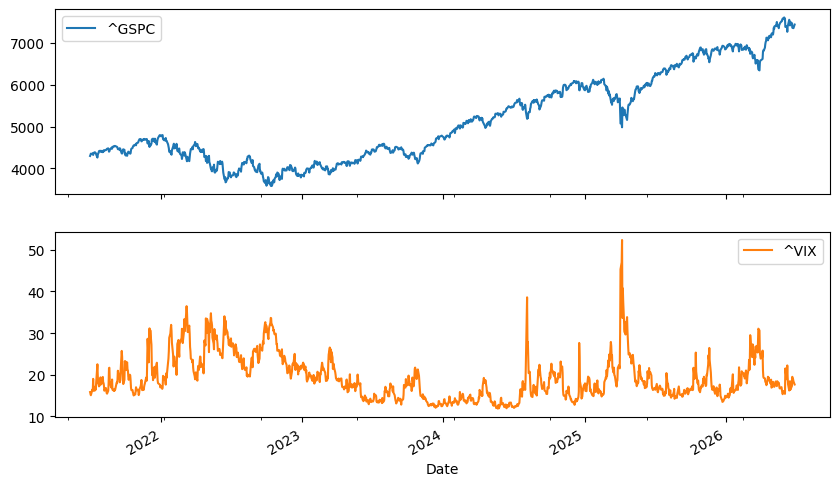

In [99]:
data.plot(subplots=True , figsize=(10,6))

<Axes: xlabel='Date'>

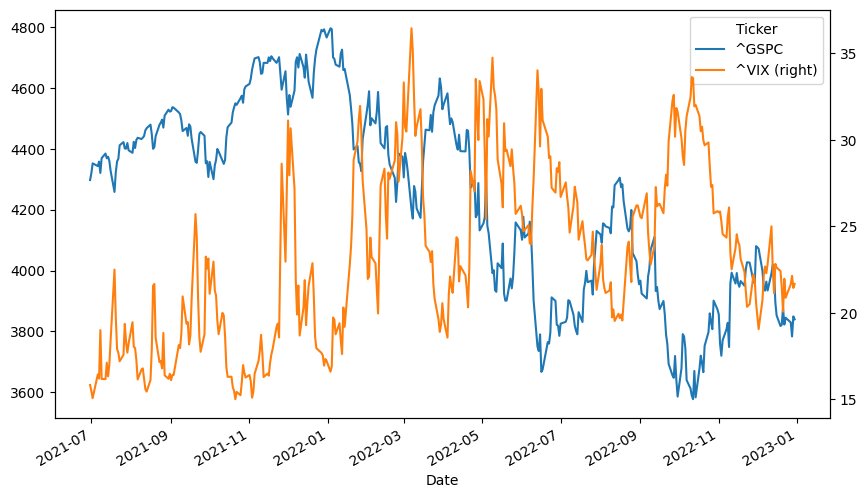

In [100]:
data.loc[:'2022-12-31'].plot(secondary_y='^VIX',figsize=(10,6))

When plotting (parts of) the two time series in a single plot and with adjusted scal‐
ings, the stylized fact of negative correlation between the two indices becomes evident
through simple visual inspection

## Logarithmic Returns

As pointed out earlier, statistical analysis in general relies on returns instead of abso‐
lute changes or even absolute values. Therefore, we’ll calculate log returns first before
any further analysis takes place

below results shows that high variability of the log
returns over time. For both indices so-called “volatility clusters” can be spotted. In
general, periods of high volatility in the stock index are accompanied by the same
phenomena in the volatility index

In [101]:
import numpy as np

In [102]:
rets = np.log(data/data.shift(1))

In [103]:
rets.dropna()

Ticker,^GSPC,^VIX
Date,,
2021-07-01,0.005208,-0.022358
2021-07-02,0.007472,-0.026843
2021-07-06,-0.002024,0.087011
2021-07-07,0.003353,-0.014706
2021-07-08,-0.008598,0.159428
...,...,...
2026-06-23,-0.014467,0.120352
2026-06-24,-0.000983,-0.045128
2026-06-25,-0.000099,0.013860


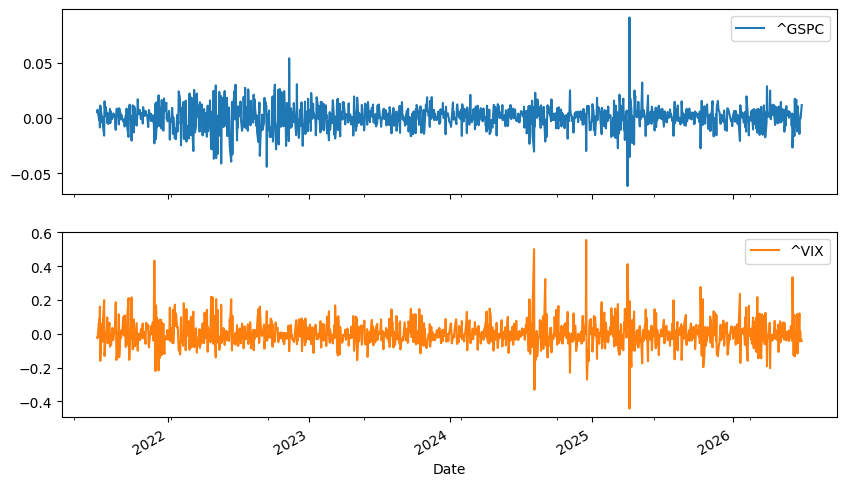

In [104]:
rets.plot(subplots=True,figsize=(10,6));


In such a context, the pandas scatter_matrix() plotting function comes in handy
for visualizations. It plots the log returns of the two series against each other, and one
can add either a histogram or a kernel density estimator (KDE) on the diagonal 

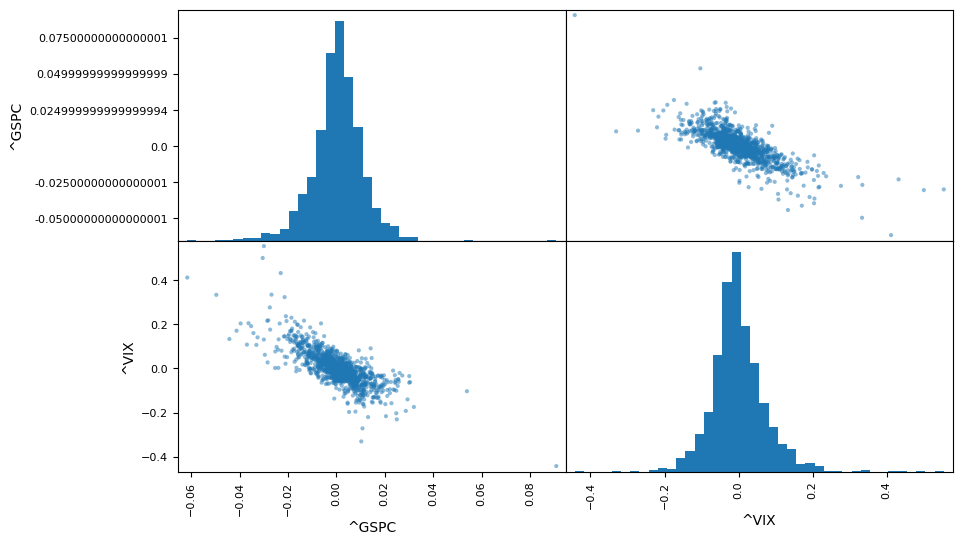

In [105]:
pd.plotting.scatter_matrix(rets,
                           alpha=0.5,
                           diagonal='hist',
                           hist_kwds={'bins':40},
                           figsize=(10,6));

## OLS Regression

### Ordinary Least Squares (OLS)
is a fundamental statistical method used in linear regression to estimate the relationship between a dependent variable (the target you want to predict) and one or more independent variables (the features you use to make the prediction).

The primary goal of OLS is to draw the "line of best fit" through a set of data points by minimizing the errors between the actual observed values and the values predicted by that line.

### How It Works
When you draw a straight line through a scatterplot of data, there is almost always a gap between the actual data points and the line itself. This vertical gap is called a residual (or error).

OLS works by squaring these residuals (to ensure negative and positive errors do not cancel each other out, and to penalize larger errors more heavily) and adding them all together. The algorithm then mathematically adjusts the slope and intercept of the line until this Sum of Squared Residuals (SSR) reaches its absolute minimum possible value.

an ordinary least-squares (OLS) regression analysis is
convenient to implement.

In [106]:
rets = rets.dropna()

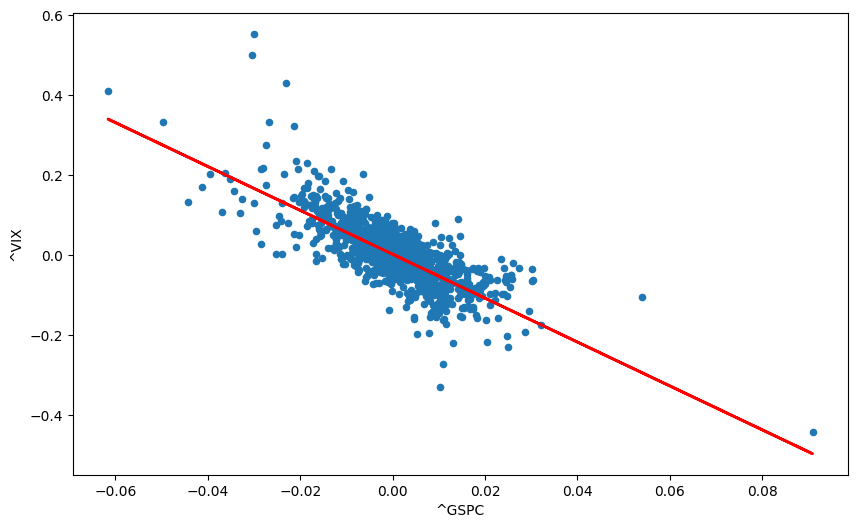

In [107]:
reg = np.polyfit(rets['^GSPC'],rets['^VIX'],deg=1)

ax = rets.plot(kind='scatter',x='^GSPC',y='^VIX',figsize=(10,6))
ax.plot(rets['^GSPC'],np.polyval(reg,rets['^GSPC']),'r',lw=2);

The slope is obviously negative, pro‐
viding support for the stylized fact about the negative correlation between the two
indices.

### Correlation


In [108]:
# The Correlation MAtrix for the Whole Data Frame
rets.corr()

Ticker,^GSPC,^VIX
Ticker,,
^GSPC,1.000000,-0.768346
^VIX,-0.768346,1.000000


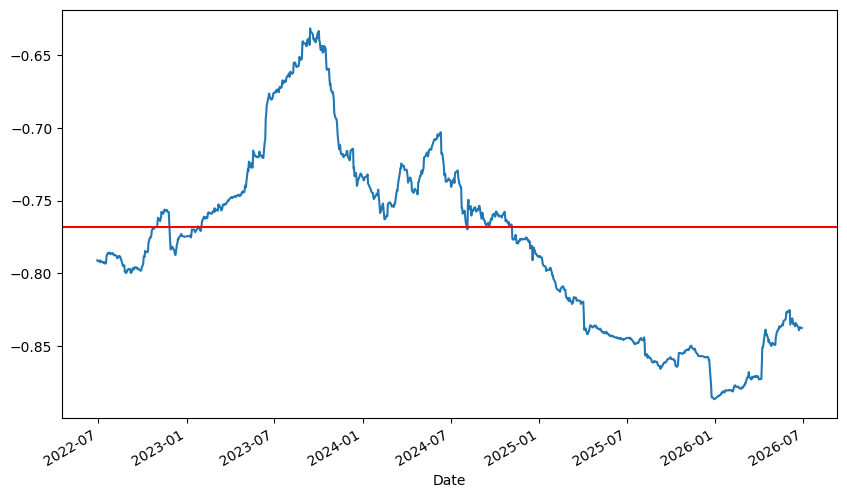

In [109]:
# plots the rolling correlation over time  and add static value given by corr function to the plot as horizontal line 
ax = rets['^GSPC'].rolling(252).corr(rets['^VIX']).plot(figsize=(10,6))
ax.axhline(rets.corr().iloc[0,1],c='r')

# Dealing with High Frequency Data 

In [110]:
%%time 
tick = pd.read_csv('fxcm_eur_usd_tick_data.csv',index_col=0,parse_dates=True)


CPU times: total: 15.6 ms
Wall time: 17.5 ms


In [111]:
tick.head()

,Bid,Ask
2017-11-10 12:00:00.007,1.16395,1.16394
2017-11-10 12:00:00.053,1.16394,1.16394
2017-11-10 12:00:00.740,1.16394,1.16393
2017-11-10 12:00:00.746,1.16394,1.16391
2017-11-10 12:00:00.756,1.16394,1.16392


<Axes: >

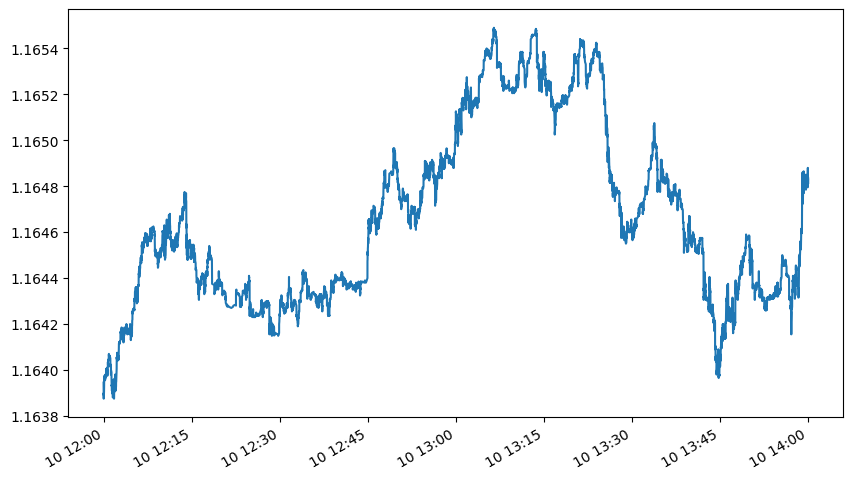

In [112]:
tick['Mid'] = tick.mean(axis=1)
tick['Mid'].plot(figsize=(10,6))

In [113]:
tick_resam = tick.resample(rule='5min', label='right').last()
tick_resam.head()

,Bid,Ask,Mid
2017-11-10 12:05:00,1.16425,1.16427,1.164260
2017-11-10 12:10:00,1.16454,1.16455,1.164545
2017-11-10 12:15:00,1.16449,1.16449,1.164490
2017-11-10 12:20:00,1.16437,1.16437,1.164370
2017-11-10 12:25:00,1.16429,1.16430,1.164295


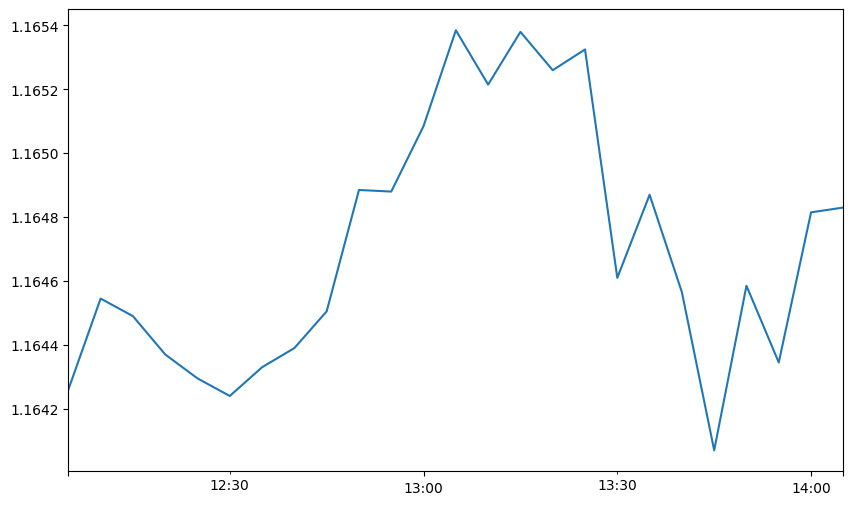

In [114]:
tick_resam['Mid'].plot(figsize=(10,6));